# Prédiction des propriétés mécaniques des soudures

**Revue et améliorations : El Houssine KAMILI — @elhoussine-arise.** Le travail initial de l’équipe reste accessible dans l’historique Git.

Cette version corrige le nettoyage, la définition de Charpy et la validation; elle conserve RF et XGBoost et ajoute des modèles de référence et un véritable test semi-supervisé. Les sorties ci-dessous viennent des scripts réellement exécutés. [Audit détaillé](docs/AUDIT_COMPARATIF.md).

## 1. Charger et vérifier les données

Les 44 colonnes sont décrites par Cambridge. `N` signifie valeur non rapportée, jamais zéro. La colonne chimique `N` désigne l’azote. Les notations censurées, totales/résiduelles et intervalles sont traitées par `src/data.py`; les champs ambigus restent inconnus avec indicateur.

La source brute est conservée. Le seuil de présence 60 % est appris par pli sur les seules entrées numériques d’entraînement; aucune ligne n’est globalement supprimée pour une entrée manquante.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd()
assert (ROOT / "src/data.py").exists(), "Ouvrir le notebook depuis la racine du dépôt."
sys.path.insert(0, str(ROOT / "src"))
from data import load_data, TARGETS, feature_names
raw, data, audit = load_data()
print("Dimensions brutes :", raw.shape)
print("Compositions observées :", data.composition_group.nunique())
display(audit)


Dimensions brutes : (1652, 44)
Compositions observées : 624


variable,censored,ambiguous_set_missing
S,7,0
Mo,2,0
V,308,9
Cu,14,0
Co,21,0
W,12,0
Ti,70,16
Al,403,16
B,419,0
Nb,299,0


## 2. Définir les cibles avant les modèles

Les résistances, allongement et réduction de section sont des propriétés continues. Charpy a deux tâches distinctes : énergie à une température d’essai connue; température d’un point observé à **100 J**. Une température observée à énergie variable n’est pas une température de transition universelle.

Les autres propriétés mécaniques, microstructures, dureté et ID sont exclus des entrées. Il n’existe pas de verdict industriel de « bonne qualité » dans la base. Les classes du self-training sont relatives et explicitement illustratives.

In [2]:
display(data[TARGETS].describe().T.reset_index().rename(columns={"index":"target"}).round(3))
print("100 J :", int(data.charpy_energy.eq(100).sum()))
print("28 J :", int(data.charpy_energy.eq(28).sum()))
print("U Charpy avec température connue :", int((data.charpy_energy.isna() & data.charpy_temperature.notna()).sum()))


100 J : 356
28 J : 118
U Charpy avec température connue : 0


target,count,mean,std,min,25%,50%,75%,max
yield_strength,780.0,508.557,92.865,315.0,443.000,495.0,559.25,920.0
tensile_strength,738.0,594.386,88.636,447.0,532.775,575.5,647.00,1151.0
elongation,700.0,26.276,4.896,10.6,22.800,26.8,30.00,37.0
reduction_area,705.0,71.800,8.927,17.0,68.000,75.0,78.00,83.0
charpy_energy,879.0,87.689,50.117,3.0,38.000,100.0,100.00,270.0
temperature_100J,356.0,-40.067,25.958,-85.0,-58.000,-45.0,-28.00,59.0


## 3. ACP descriptive

L’ACP est une visualisation des entrées numériques imputées et centrées réduites, sans cibles. Elle n’est pas une étape prédictive du benchmark. Les deux premiers axes expliquent moins de 40 % de la variance; réduire la prédiction à ces deux axes serait un choix non justifié.

PC1 21.49 % ; PC2 15.38 %
Composantes pour 80 %% : 9


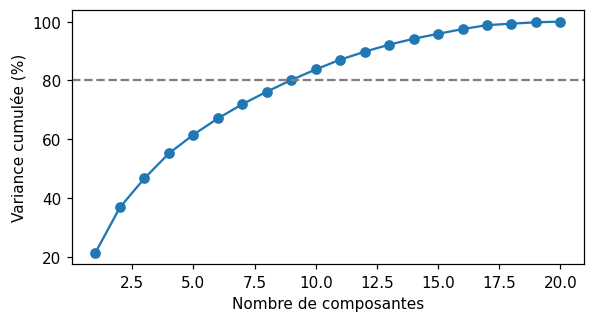

In [3]:
pca = json.loads((ROOT / "results/pca_summary.json").read_text())
print("PC1 %.2f %% ; PC2 %.2f %%" % tuple(100*v for v in pca["explained_variance_ratio"][:2]))
print("Composantes pour 80 %% :", pca["components_80pct"])
fig, ax = plt.subplots(figsize=(6,3))
r = np.cumsum(pca["explained_variance_ratio"])
ax.plot(np.arange(1,len(r)+1),100*r,"o-")
ax.axhline(80,ls="--",color="grey")
ax.set(xlabel="Nombre de composantes",ylabel="Variance cumulée (%)")
display(fig)
plt.close(fig)


## 4. Prétraitement et validation sans fuite

Le filtre des absences, l’imputation médiane, les indicateurs, le scaling et le one-hot sont ajustés sur l’entraînement de chaque pli. La même composition reste dans un seul côté du split. Cinq plis externes évaluent chaque famille; trois plis internes règlent les hyperparamètres par MAE. Les groupes de validation/test sont également exclus de U.

Les cibles sont standardisées au fit et restituées en unités physiques pour MAE, RMSE et R². La MAE ne se moyenne pas entre MPa, J et °C. Les écarts types des plis ne sont pas des intervalles de confiance. Le choix de famille doit encore être testé sur une nouvelle campagne.

## 5. Modèles et comparaison sur les mêmes splits

Moyenne, Ridge, kNN, SVR, arbre, forêt, XGBoost, RFF supervisé et RFF graphe. Les grilles sont dans `src/models.py`; tous les résultats sont enregistrés dans `results/`. Les anciennes sorties de température sur 307 lignes ne sont pas comparables directement à ces nouvelles tâches et splits.

In [4]:
summary = pd.read_csv(ROOT / "results/summary_metrics.csv")
display(summary.pivot(index="model",columns="target",values="MAE_mean").round(3).reset_index())
winners = summary.sort_values("MAE_mean").groupby("target").head(1)
display(winners[["target","model","MAE_mean","MAE_sd","RMSE_mean","R2_pooled"]].round(3))


target,model,charpy_energy,elongation,reduction_area,temperature_100J,tensile_strength,yield_strength
,Arbre,22.799,2.734,3.583,15.448,40.153,45.500
,Forêt,18.260,1.946,2.640,12.549,27.505,31.459
,Moyenne,38.926,4.047,6.745,19.709,70.158,71.723
,RFF graphe,26.492,2.586,3.530,14.691,35.485,43.113
,RFF supervisé,26.425,2.585,3.518,14.710,35.382,43.061
,Ridge,32.367,2.347,3.157,15.902,33.500,45.142
,SVR RBF,22.974,1.883,2.489,12.289,20.083,26.502
,XGBoost,19.093,1.969,2.757,12.979,23.844,28.342
,kNN,22.341,2.177,2.770,13.429,30.321,36.317


target,model,MAE_mean,MAE_sd,RMSE_mean,R2_pooled
elongation,SVR RBF,1.883,0.141,2.691,0.695
reduction_area,SVR RBF,2.489,0.527,4.596,0.717
temperature_100J,SVR RBF,12.289,1.841,18.433,0.484
charpy_energy,Forêt,18.260,4.320,29.071,0.648
tensile_strength,SVR RBF,20.083,1.668,31.518,0.871
yield_strength,SVR RBF,26.502,2.506,42.511,0.787


## 6. Vérifier les prédictions hors pli

Chaque mesure est prédite par un modèle qui n’a vu ni sa composition ni ses labels durant son entraînement externe. Le graphique T100 ci-dessous utilise ces prédictions; le modèle final réentraîné sur tous les labels n’a pas de nouveau score indépendant.

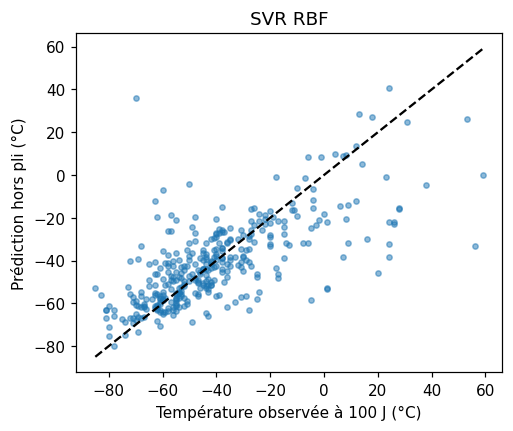

In [5]:
oof_path = ROOT / "results/oof_predictions.csv"
if oof_path.exists():
    oof = pd.read_csv(oof_path)
    name = winners[winners.target.eq("temperature_100J")].iloc[0]["model"]
    points = oof[oof.target.eq("temperature_100J") & oof.model.eq(name)]
    fig, ax = plt.subplots(figsize=(5,4))
    ax.scatter(points.observed,points.predicted,s=12,alpha=.5)
    lo=min(points.observed.min(),points.predicted.min())
    hi=max(points.observed.max(),points.predicted.max())
    ax.plot([lo,hi],[lo,hi],"k--")
    ax.set(xlabel="Température observée à 100 J (°C)",ylabel="Prédiction hors pli (°C)",title=name)
    display(fig)
    plt.close(fig)
else:
    print("Exécuter src/run.py --mode full pour recréer les prédictions hors pli non versionnées.")


## 7. Régression semi-supervisée par graphe

L et U construisent un graphe kNN de voisinages d’entrées. Les 96 features de Fourier approximent un noyau RBF. Le modèle minimise une perte sur **L seulement**, une pénalité ridge et une pénalité de différences de prédictions entre voisins. RFF supervisé est la même méthode avec β=0. Le test n’est pas inclus dans le graphe.

Les U ne garantissent pas un gain : la géométrie des entrées doit correspondre à la fonction cible. Pour Charpy énergie, aucun U naturel n’est utilisable à température connue; le graphe y est supervisé. Pour T100 et les autres propriétés, des pools U existent. Ce résultat distingue un algorithme semi-supervisé réel de la simple invocation de sa classe.

In [6]:
graph = summary[summary.model.isin(["RFF supervisé","RFF graphe"])]
display(graph[["target","model","MAE_mean","R2_pooled"]].round(3))


target,model,MAE_mean,R2_pooled
charpy_energy,RFF supervisé,26.425,0.546
charpy_energy,RFF graphe,26.492,0.544
elongation,RFF supervisé,2.585,0.535
elongation,RFF graphe,2.586,0.535
reduction_area,RFF supervisé,3.518,0.594
reduction_area,RFF graphe,3.530,0.587
temperature_100J,RFF graphe,14.691,0.411
temperature_100J,RFF supervisé,14.710,0.408
tensile_strength,RFF supervisé,35.382,0.648
tensile_strength,RFF graphe,35.485,0.648


## 8. Véritable self-training et contrôle supervisé

Classe 1 : température du point 100 J inférieure ou égale à la médiane des seuls labels visibles d’entraînement. Ce n’est pas une norme industrielle. Les paramètres et le seuil de confiance 0,9 sont fixes; la probabilité RF n’est pas prétendue calibrée.

Pour 25 %, 50 % et 100 % des groupes labellisés conservés, comparer RF et self-training avec les mêmes labels visibles et tests. Les autres labels sont cachés et U naturel est ajouté. Les groupes du test restent exclus. Chaque fraction/pli a un seul tirage : l’expérience est exploratoire.

In [7]:
semi = pd.read_csv(ROOT / "results/self_training_metrics.csv")
display(semi.groupby(["fraction_labelled_groups","model"])[["accuracy","balanced_accuracy","F1","n_pseudo_labels_added"]].mean().round(3).reset_index())
print("Tous les fits self-training ont des U :", bool((semi.loc[semi.model.eq("RF self-training"),"n_unlabelled_supplied"]>0).all()))


Tous les fits self-training ont des U : True


fraction_labelled_groups,model,accuracy,balanced_accuracy,F1,n_pseudo_labels_added
0.25,RF self-training,0.666,0.668,0.671,552.2
0.25,RF supervised,0.677,0.678,0.690,0.0
0.50,RF self-training,0.719,0.726,0.732,401.0
0.50,RF supervised,0.713,0.717,0.724,0.0
1.00,RF self-training,0.753,0.753,0.747,555.4
1.00,RF supervised,0.772,0.773,0.770,0.0


## 9. Sensibilités et interprétation

Les sensibilités emploient une forêt fixe, distincte du benchmark réglé. Comparer splits de lignes, compositions et familles de sources; supprimer T pour la tâche énergie; varier la représentation des concentrations censurées. Les préfixes de sources ne sont pas des identifiants de publications certifiés.

Les importances par permutation sont mesurées sur les tests externes. Une importance ne donne ni direction ni causalité, et n’autorise pas une recette métallurgique universelle.

In [8]:
sensitivity = pd.read_csv(ROOT / "results/sensitivity_metrics.csv")
display(sensitivity.groupby(["target","protocol"])[["MAE","RMSE","R2"]].mean().round(3).reset_index())


target,protocol,MAE,RMSE,R2
charpy_energy,censor_fraction_0.0,19.506,30.094,0.628
charpy_energy,censor_fraction_1.0,19.347,29.860,0.634
charpy_energy,composition,19.369,29.878,0.634
charpy_energy,rows,16.621,23.631,0.773
charpy_energy,source,39.704,50.101,0.052
charpy_energy,without_charpy_temperature,32.905,45.331,0.171
yield_strength,censor_fraction_0.0,33.649,47.846,0.732
yield_strength,censor_fraction_1.0,33.878,47.851,0.732
yield_strength,composition,33.475,47.731,0.733
yield_strength,rows,30.771,43.193,0.780


## 10. Reproduction, conclusions et limites

```bash
python -m pip install -r requirements.txt
python -m unittest discover -s tests -v
python src/run.py --mode full
python src/charpy_checks.py
python src/self_training.py
```

Les conclusions doivent s’appuyer sur `docs/RESULTS.md`, sans généraliser un gain ou une conformité non démontrée. Contrôler simultanément résistance, ductilité et choc à température connue; présélectionner les recettes et vérifier par essais. Une nouvelle campagne doit confirmer le modèle retenu.

[Cambridge](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html) · [Belkin et al.](https://www.jmlr.org/papers/v7/belkin06a.html) · [scikit-learn](https://scikit-learn.org/stable/modules/semi_supervised.html).